# ___Summary of hOUwie model fits___
-------------------------------

In [1]:
print(R.version$version.string)

[1] "R version 4.6.1 (2026-06-24 ucrt)"


In [2]:
suppressPackageStartupMessages({
    library("ape")
    library("phytools")
    library("corHMM")
    library("OUwie")
})

source("../houwie_patches.R")

options(repr.plot.width = 25, repr.plot.height = 15)

In [3]:
packageVersion("OUwie")

[1] '3.0.3'

In [4]:
packageVersion("corHMM")

[1] '2.8'

In [5]:
# the OUMA and OUMVA model issues have been fixed in OUwie versions 3.00 and up, see the below page for details
# https://thej022214.github.io/OUwie/articles/calculationUpdate.html

In [6]:
#--------------------------
# helper functions
#--------------------------

STATE_COLOURS <- c(AM = "#E7BC0C", EcM = "#23B9AF", ErM = "#6B6CF2", NM = "#11E823", NMAM = "#2D2E30", EcMAM = "#E71A23")

read_all_rds <- function(dirpath, cd, strip, rm_underscores = TRUE) {
    # dirpath = path to the directory containing the .Rds files
    # cd = character dependent or independent models, these are expected to contain "CD" or "CID" in their names
    # strip = the regex pattern to strip out of the file names when naming objects, can be a plain string as well
    # rm_underscores - strip all the underscores in the object name

    fnames <- list.files(dirpath) # all the files in the specified dir
    if(cd) fnames <- fnames[grep(pattern = "CD", fnames)]
    else fnames <- fnames[grep(pattern = "CID", fnames)] # cherry pick CD or CID models, given their names contain "CD" or "CID" to distinguish them
    # print(fnames)

    paths <- paste0(dirpath, fnames) # relative paths for all the Rds files
    stopifnot(length(fnames)==length(paths))

    # remove the unnecessary parts of the file names to create the model names and also remove all the underscores
    mnames <- fnames |> gsub(pattern = ".Rds", replacement = '') |> gsub(pattern = strip, replacement = '') |> gsub(pattern = ifelse(rm_underscores, '_', ''), replacement = '')
    stopifnot(length(fnames)==length(mnames))
    stopifnot(length(paths)==length(mnames))

    models <- list()
    for (i in seq_along(mnames)) models[[mnames[i]]] <- readRDS(file = paths[i])
    stopifnot(length(models)==length(mnames))

    models
}


convergence_failures <- function(models, strip='', threshold_diff_aicc=1e10){
    model_table <- OUwie::getModelTable(models, type = "AICc") # model table from the models
    model_names <- row.names(model_table)
    model_names <- gsub(pattern = strip, replacement = '', x = model_names) # strip off the specified pattern from the names
    
    aiccs <- model_table[, "AICc"] # this becomes a hard requirement of the function, that the input dataframe needs to have a column named "AICc"
    # so the criteria is that the absoulte difference between the AICc of a given model and the highest AICc (worst fit) shouldn't exceed 1e5, else it's considered a convergence failure
    model_names[abs(aiccs - max(aiccs)) >= threshold_diff_aicc]  # with an option provided to pass in a custom difference threshold
}


plot_model_averages <- function(data){
    # the data argument is expected to be the untouched output of the OUwie::getModelAvgParams() function
    stopifnot(is.data.frame(data))
    
    options(repr.plot.width = 15, repr.plot.height = 15)
    par(mfrow = c(2, 2), mar = c(3, 4, 0, 0), mgp = c(2.25, 0.75, 0))

    boxplot(formula = rates ~ tip_state, data = data, xlab = NULL, ylab = "Rates", border = STATE_COLOURS, col = "white")
    boxplot(formula = alpha ~ tip_state, data = data, xlab = NULL, ylab = expression(alpha), border = STATE_COLOURS, col = "white")
    boxplot(formula = sigma.sq ~ tip_state, data = data, xlab = NULL, ylab = expression(sigma^2), border = STATE_COLOURS, col = "white")
    boxplot(formula = theta ~ tip_state, data = data, xlab = NULL, ylab = expression(theta), border = STATE_COLOURS, col = "white")
}

In [8]:
# find out the AIC and AICc of all the models

# OUwie::getModelAvgParams()
# type - one of AIC, BIC, or AICc for use during evaluation of relative model fit.
# AICc (small sample size corrected AIC) is the best option for datasets with a few number of species.
# force - a boolean indicating whether to force potentially failed model fits to be included in the model averaging.

# look up to see what the BIC stuff is about https://www.rdocumentation.org/packages/AICcmodavg/versions/2.3-4/topics/bictabCustom
# AIC vs BIC https://fiveable.me/bayesian-statistics/unit-11/bayesian-information-criterion/study-guide/o3iS2biLgz7mcyuv

## ___1. 995 species, 5 mycorrhizal states and FRED 3.0___
------------------------------

In [6]:
#---------------
# root diameter
#---------------

rd_995_cd <- read_all_rds(dirpath = "../../data/chapter2/rdata/parallel/LOG_RD_995SP_100SIMS/", cd = TRUE, strip = "F00679_CD")
rd_995_cid <- read_all_rds(dirpath = "../../data/chapter2/rdata/parallel/LOG_RD_995SP_100SIMS/", cd = FALSE, strip = "F00679_CID")

In [8]:
OUwie::getModelTable(rd_995_cd, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,27,-837.7815,-222.4381,-610.7957,1731.127,14.5409887,3.748617e-04
ARDOUMA,31,-1240.7399,-224.6911,-1009.8106,2545.540,828.9543658,5.324186e-181
ARDOUMV,31,-875.8786,-222.4858,-648.7782,1815.817,99.2318326,1.525766e-22
ARDOUMVA,35,-1214.4508,-225.2339,-984.6957,2501.529,784.9436965,1.918884e-171
EROUM,8,-1307.4927,-235.9841,-1065.8242,2631.131,914.5458396,1.381341e-199
EROUMA,12,-1254.1331,-235.9806,-1017.0206,2532.584,815.9983010,3.464391e-178
EROUMV,12,-1238.7481,-235.9414,-999.0268,2501.814,785.2283279,1.664339e-171
EROUMVA,16,-1221.0799,-235.9916,-980.3370,2474.716,758.1305515,1.274821e-165
SYMOUM,17,-841.1358,-225.8393,-610.8337,1716.898,0.3124422,4.608511e-01


In [8]:
convergence_failures(models = rd_995_cd)

character(0)

In [9]:
OUwie::getModelTable(rd_995_cid, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,46,-8.660587e+02,-244.8339,-6.175052e+02,1.828679e+03,18253609577,0
ARDOUMA,47,-1.297129e+03,-245.0929,-1.054712e+03,2.693023e+03,18253610441,0
ARDOUMV,47,-1.285349e+03,-244.7591,-1.039078e+03,2.669462e+03,18253610417,0
ARDOUMVA,48,-1.277052e+03,-245.2749,-1.044505e+03,2.655076e+03,18253610403,0
EROUM,8,-8.584728e+02,-236.2650,-6.178687e+02,1.733092e+03,18253609481,0
EROUMA,9,4.294540e+09,-236.6196,-8.320778e+03,-8.589081e+09,9664527211,0
EROUMV,9,-8.728444e+02,-236.0431,-6.322679e+02,1.763872e+03,18253609512,0
EROUMVA,10,9.126804e+09,-242.6438,8.589933e+09,-1.825361e+10,0,1
SYMOUM,26,-8.853430e+02,-248.2156,-1.078624e+03,1.824136e+03,18253609572,0


In [10]:
convergence_failures(models = rd_995_cid) # two failed CID fits

[1] "EROUMA"  "EROUMVA"

In [11]:
capture.output(avg_rd_995_cd <- OUwie::getModelAvgParams(rd_995_cd, type = "AICc", force = FALSE), file = nullfile()) # OUwie::getModelAvgParams spits out a lot of stuff, we don't want that here
capture.output(avg_rd_995_cid <- OUwie::getModelAvgParams(rd_995_cid, type = "AICc", force = FALSE), file = nullfile())

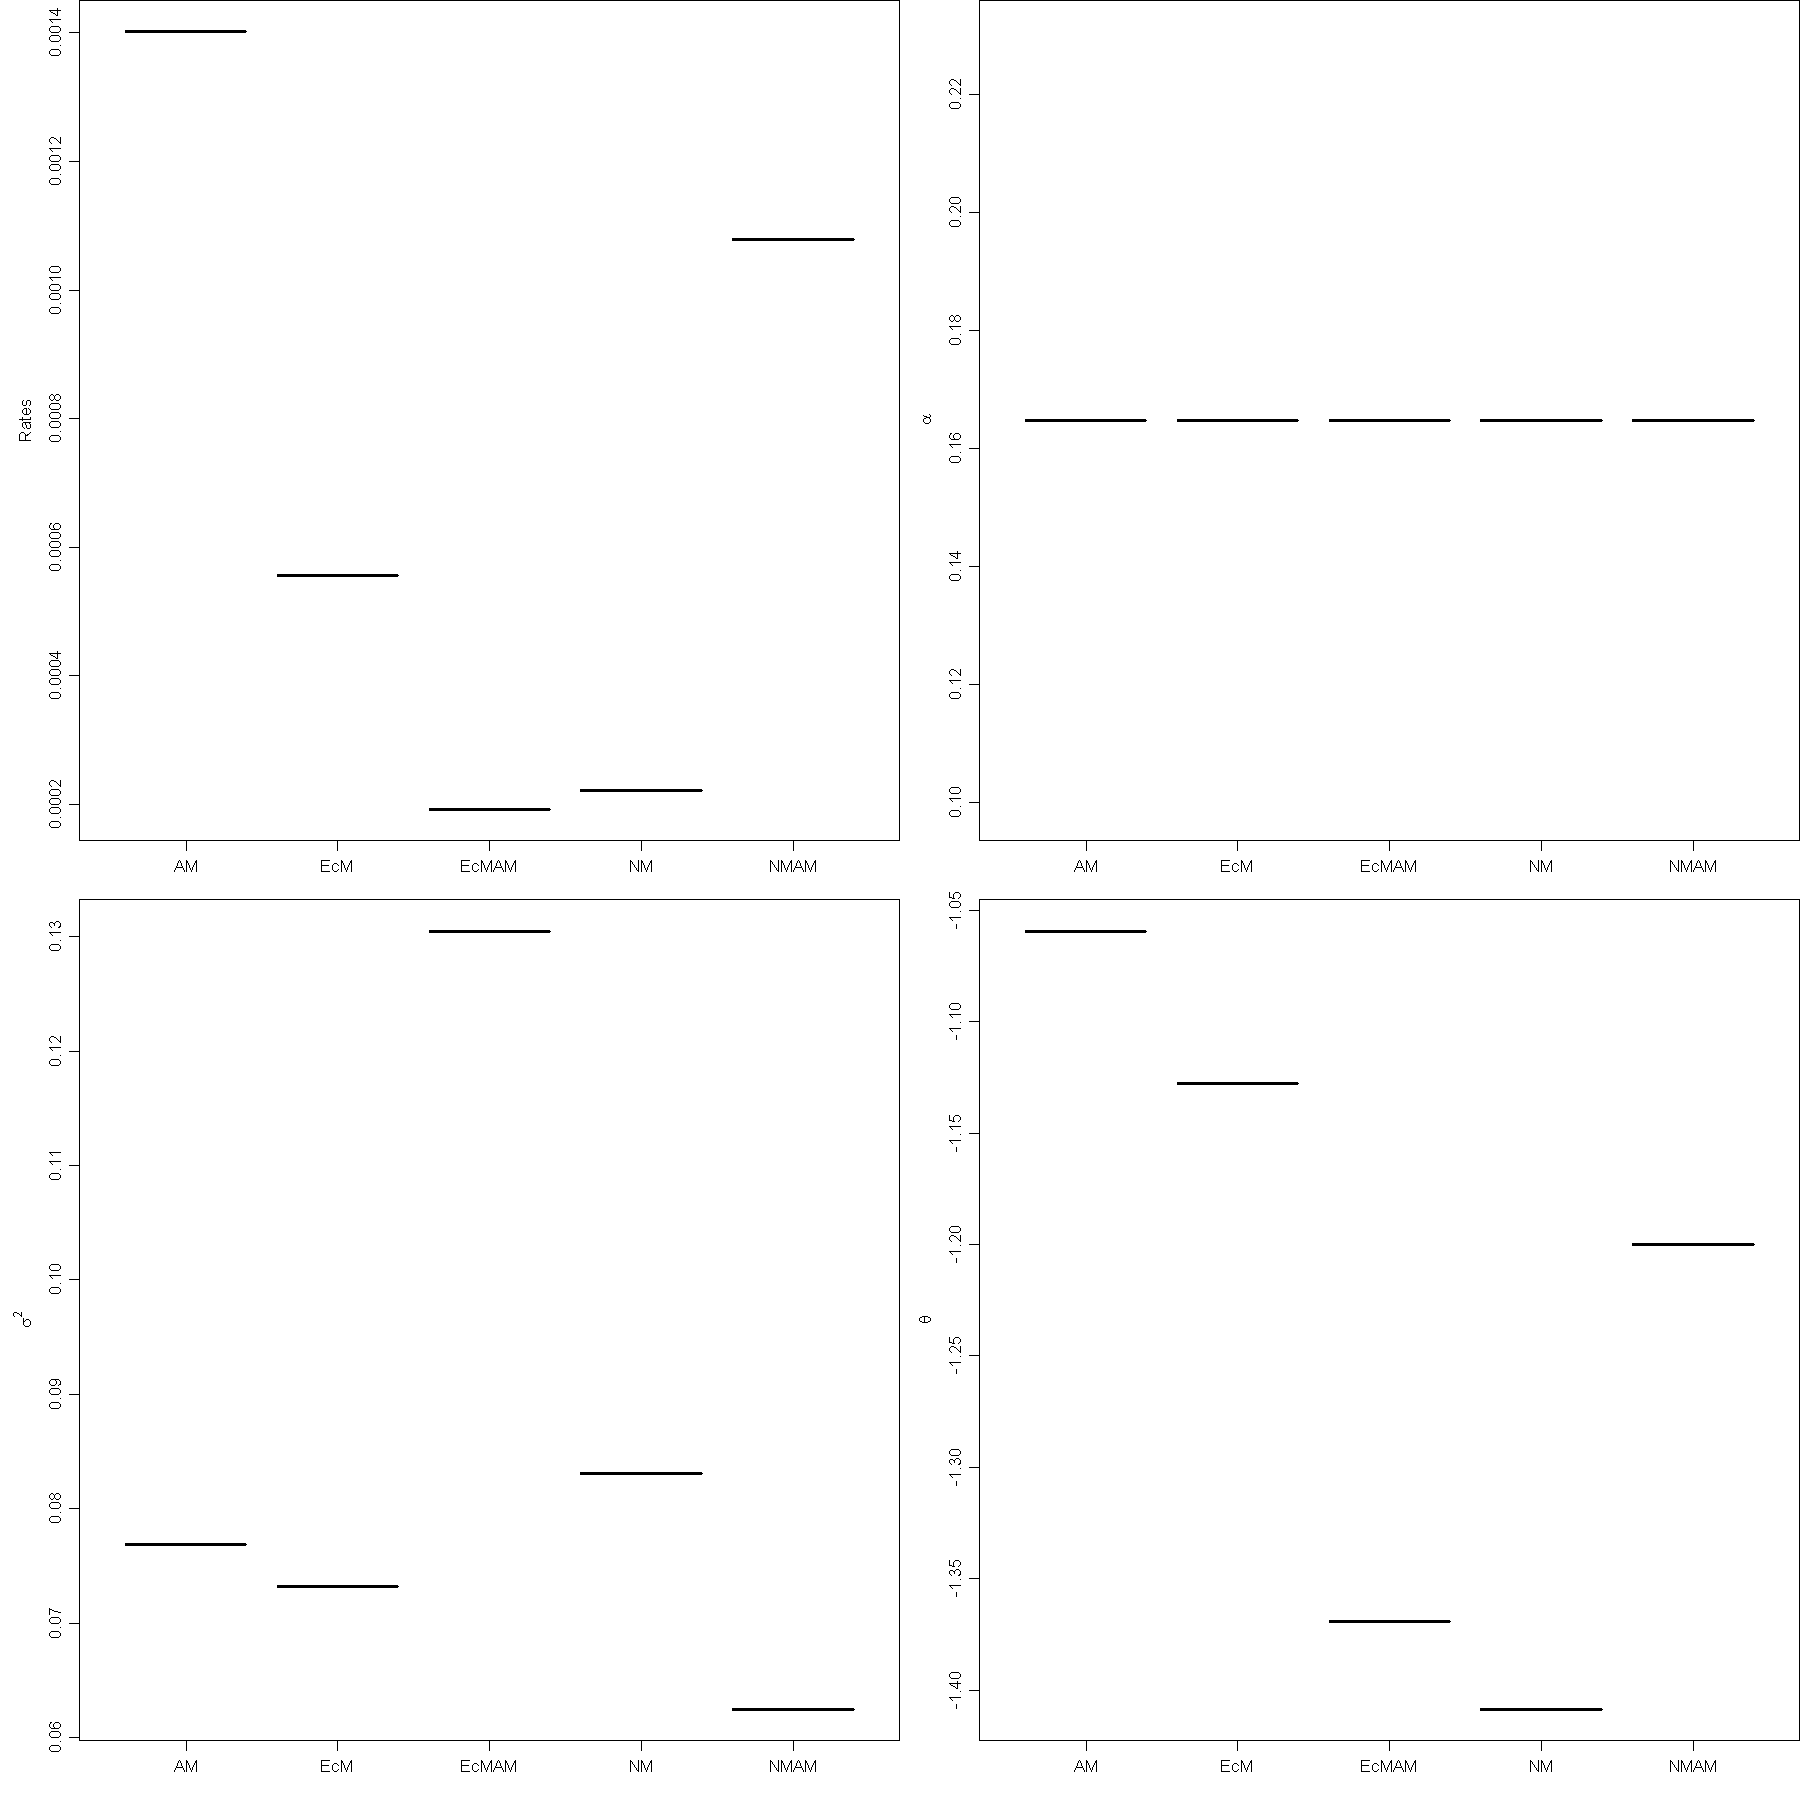

In [7]:
plot_model_averages(data = avg_rd_995_cd) # CD fits

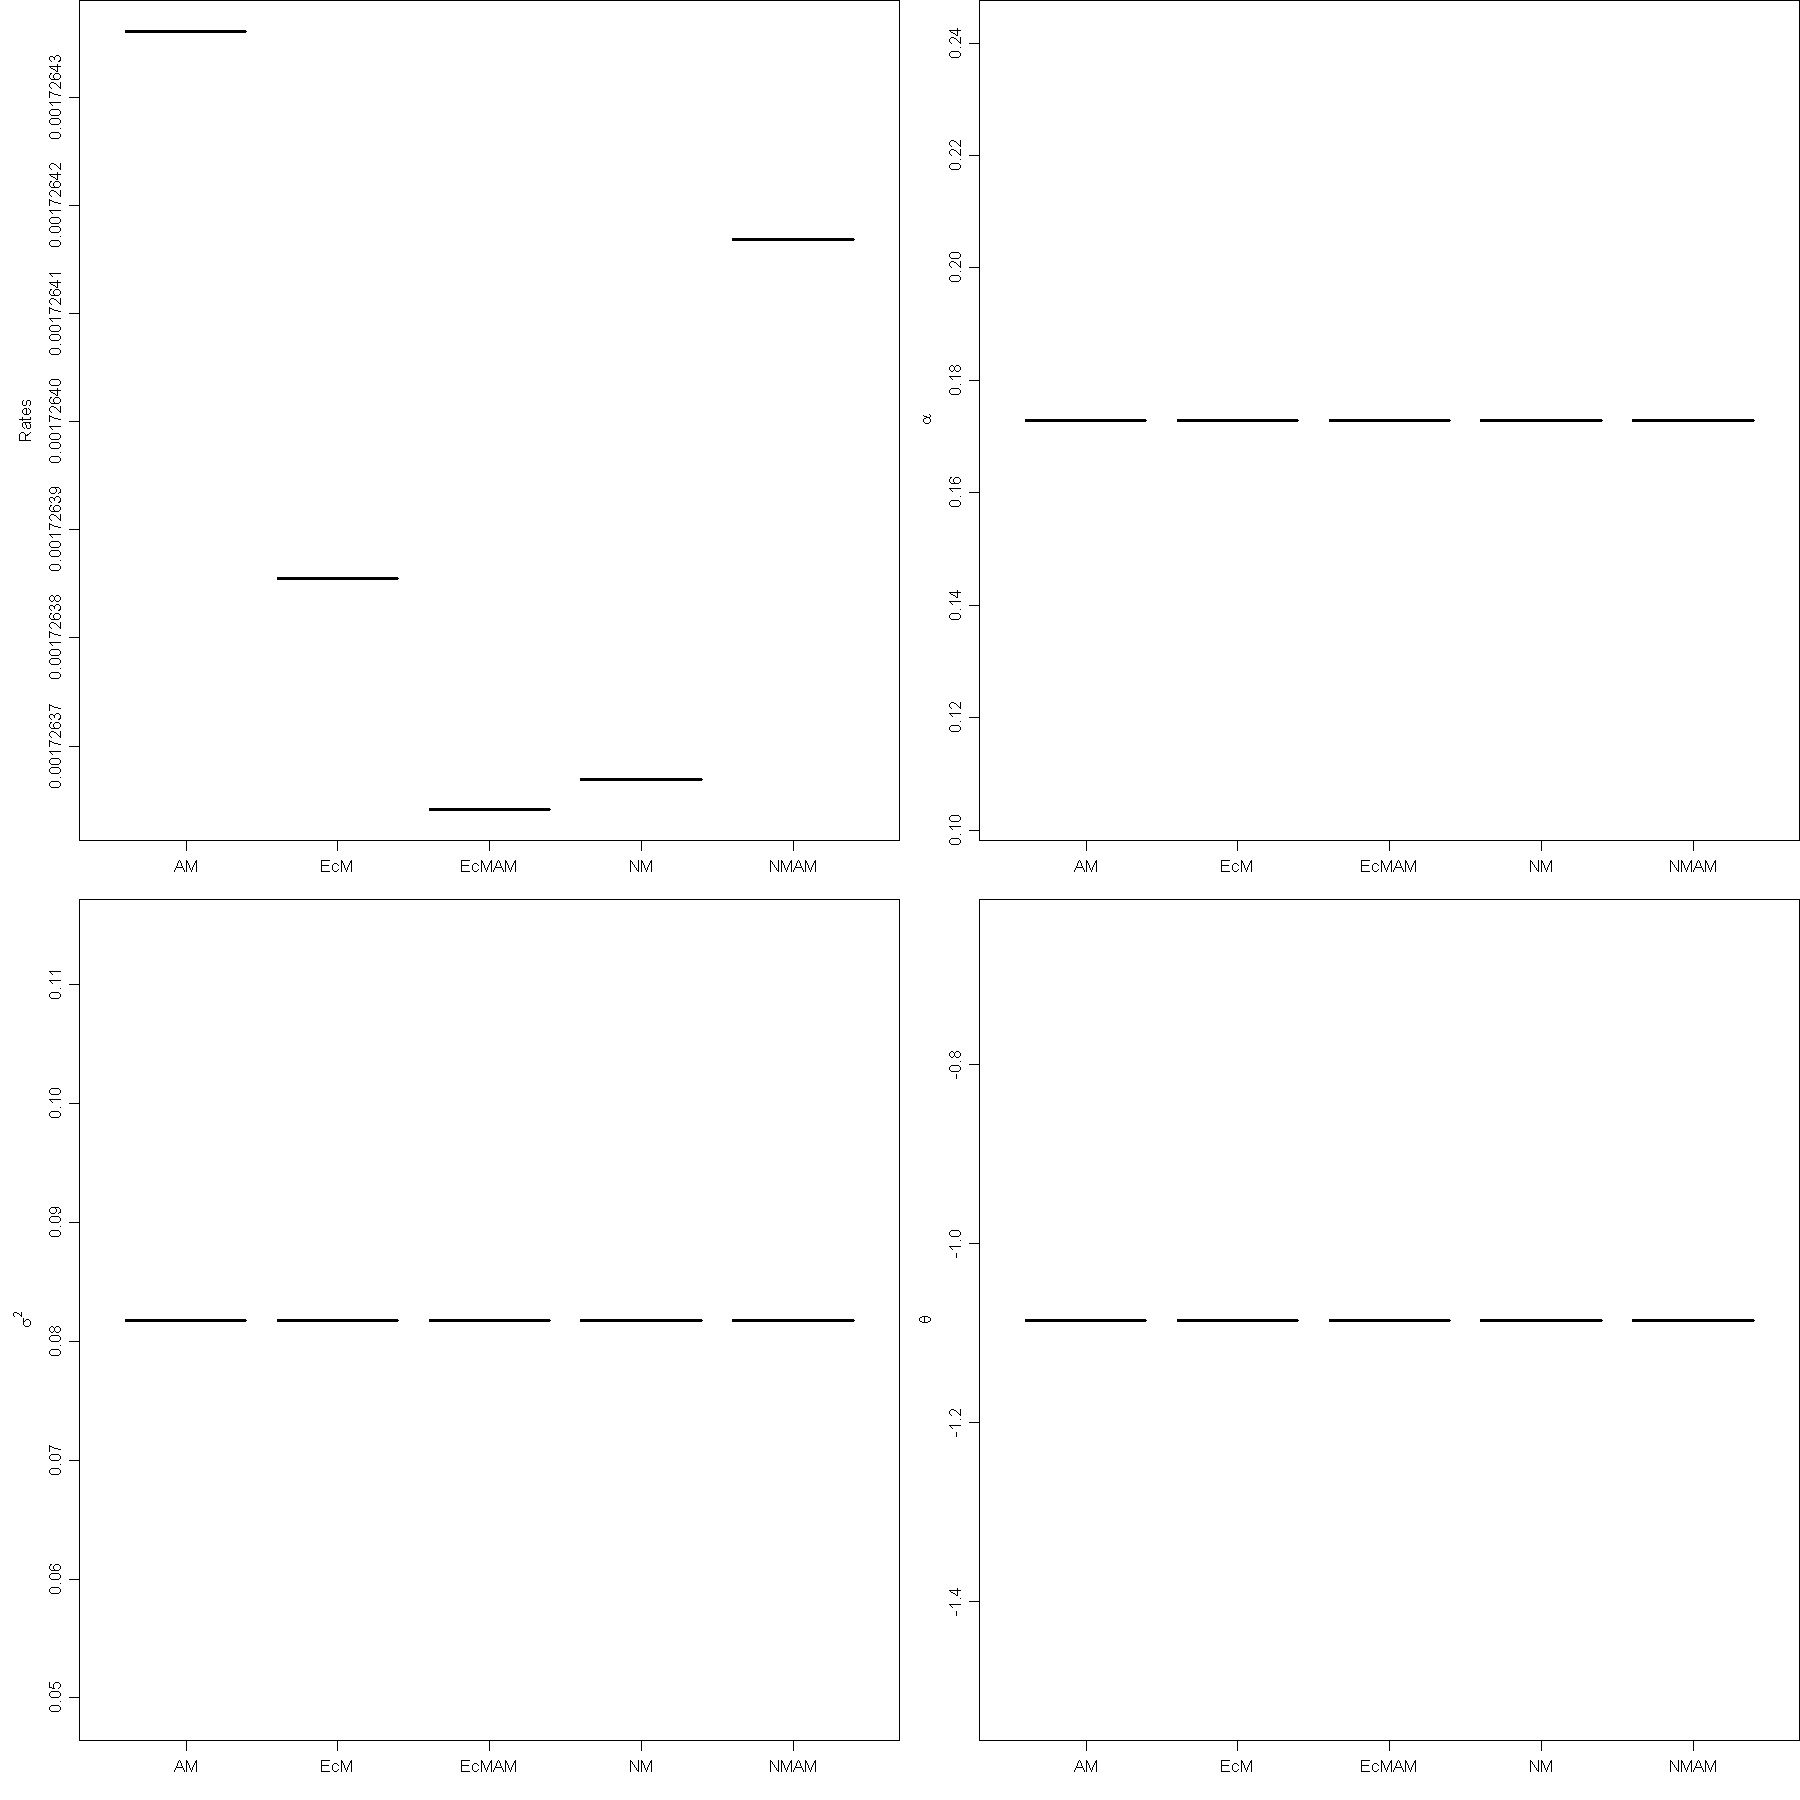

In [8]:
plot_model_averages(data = avg_rd_995_cid) # CID fits

In [12]:
#------------------------
# specific root length
#------------------------

srl_995_cd <- read_all_rds(dirpath = "../../data/chapter2/rdata/parallel/LOG_SRL_995SP_100SIMS/", cd = TRUE, strip = "F00727_CD")
srl_995_cid <- read_all_rds(dirpath = "../../data/chapter2/rdata/parallel/LOG_SRL_995SP_100SIMS/", cd = FALSE, strip = "F00727_CID")

In [13]:
OUwie::getModelTable(srl_995_cd, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,27,-1898.815,-222.4386,-1671.813,3853.194,31.503764,8.816617e-08
ARDOUMA,31,-2211.673,-224.2157,-1983.303,4487.406,665.715792,1.690090e-145
ARDOUMV,31,-2221.894,-222.3920,-1995.005,4507.848,686.158003,6.150923e-150
ARDOUMVA,35,-2164.539,-225.2221,-1934.445,4401.705,580.014976,6.880272e-127
EROUM,8,-1904.484,-235.9440,-1664.636,3825.114,3.424010,1.103426e-01
EROUMA,12,-2234.623,-235.9917,-1992.989,4493.565,671.874426,7.772836e-147
EROUMV,12,-1898.686,-235.9516,-1658.743,3821.690,0.000000,6.113043e-01
EROUMVA,16,-2198.069,-236.0035,-1958.364,4428.694,607.004213,9.483473e-133
SYMOUM,17,-1894.319,-225.8475,-1664.442,3823.263,1.573409,2.783531e-01


In [14]:
convergence_failures(srl_995_cd)

character(0)

In [15]:
OUwie::getModelTable(srl_995_cid, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,46,-2.280617e+03,-265.4901,-2025.149,4.657795e+03,17179870052,0
ARDOUMA,47,-2.174983e+03,-262.8171,-2053.463,4.448731e+03,17179869842,0
ARDOUMV,47,-2.249811e+03,-260.8590,-2026.660,4.598387e+03,17179869992,0
ARDOUMVA,48,-2.085369e+03,-268.5176,-1833.000,4.271710e+03,17179869665,0
EROUM,8,-2.265167e+03,-235.9243,-2024.658,4.546480e+03,17179869940,0
EROUMA,9,8.589933e+09,-236.3958,536869234.335,-1.717987e+10,0,1
EROUMV,9,-1.913447e+03,-235.9671,-1673.154,3.845077e+03,17179869239,0
EROUMVA,10,-2.144410e+03,-237.5550,-2013.270,4.309044e+03,17179869703,0
SYMOUM,26,-1.919728e+03,-250.2099,-1734.309,3.892906e+03,17179869287,0


In [16]:
convergence_failures(srl_995_cid) # two failures

[1] "EROUMA"  "SYMOUMA"

In [16]:
capture.output(avg_srl_995_cd <- OUwie::getModelAvgParams(srl_995_cd, type = "AICc", force = FALSE), file = nullfile())
capture.output(avg_srl_995_cid <- OUwie::getModelAvgParams(srl_995_cid, type = "AICc", force = FALSE), file = nullfile())

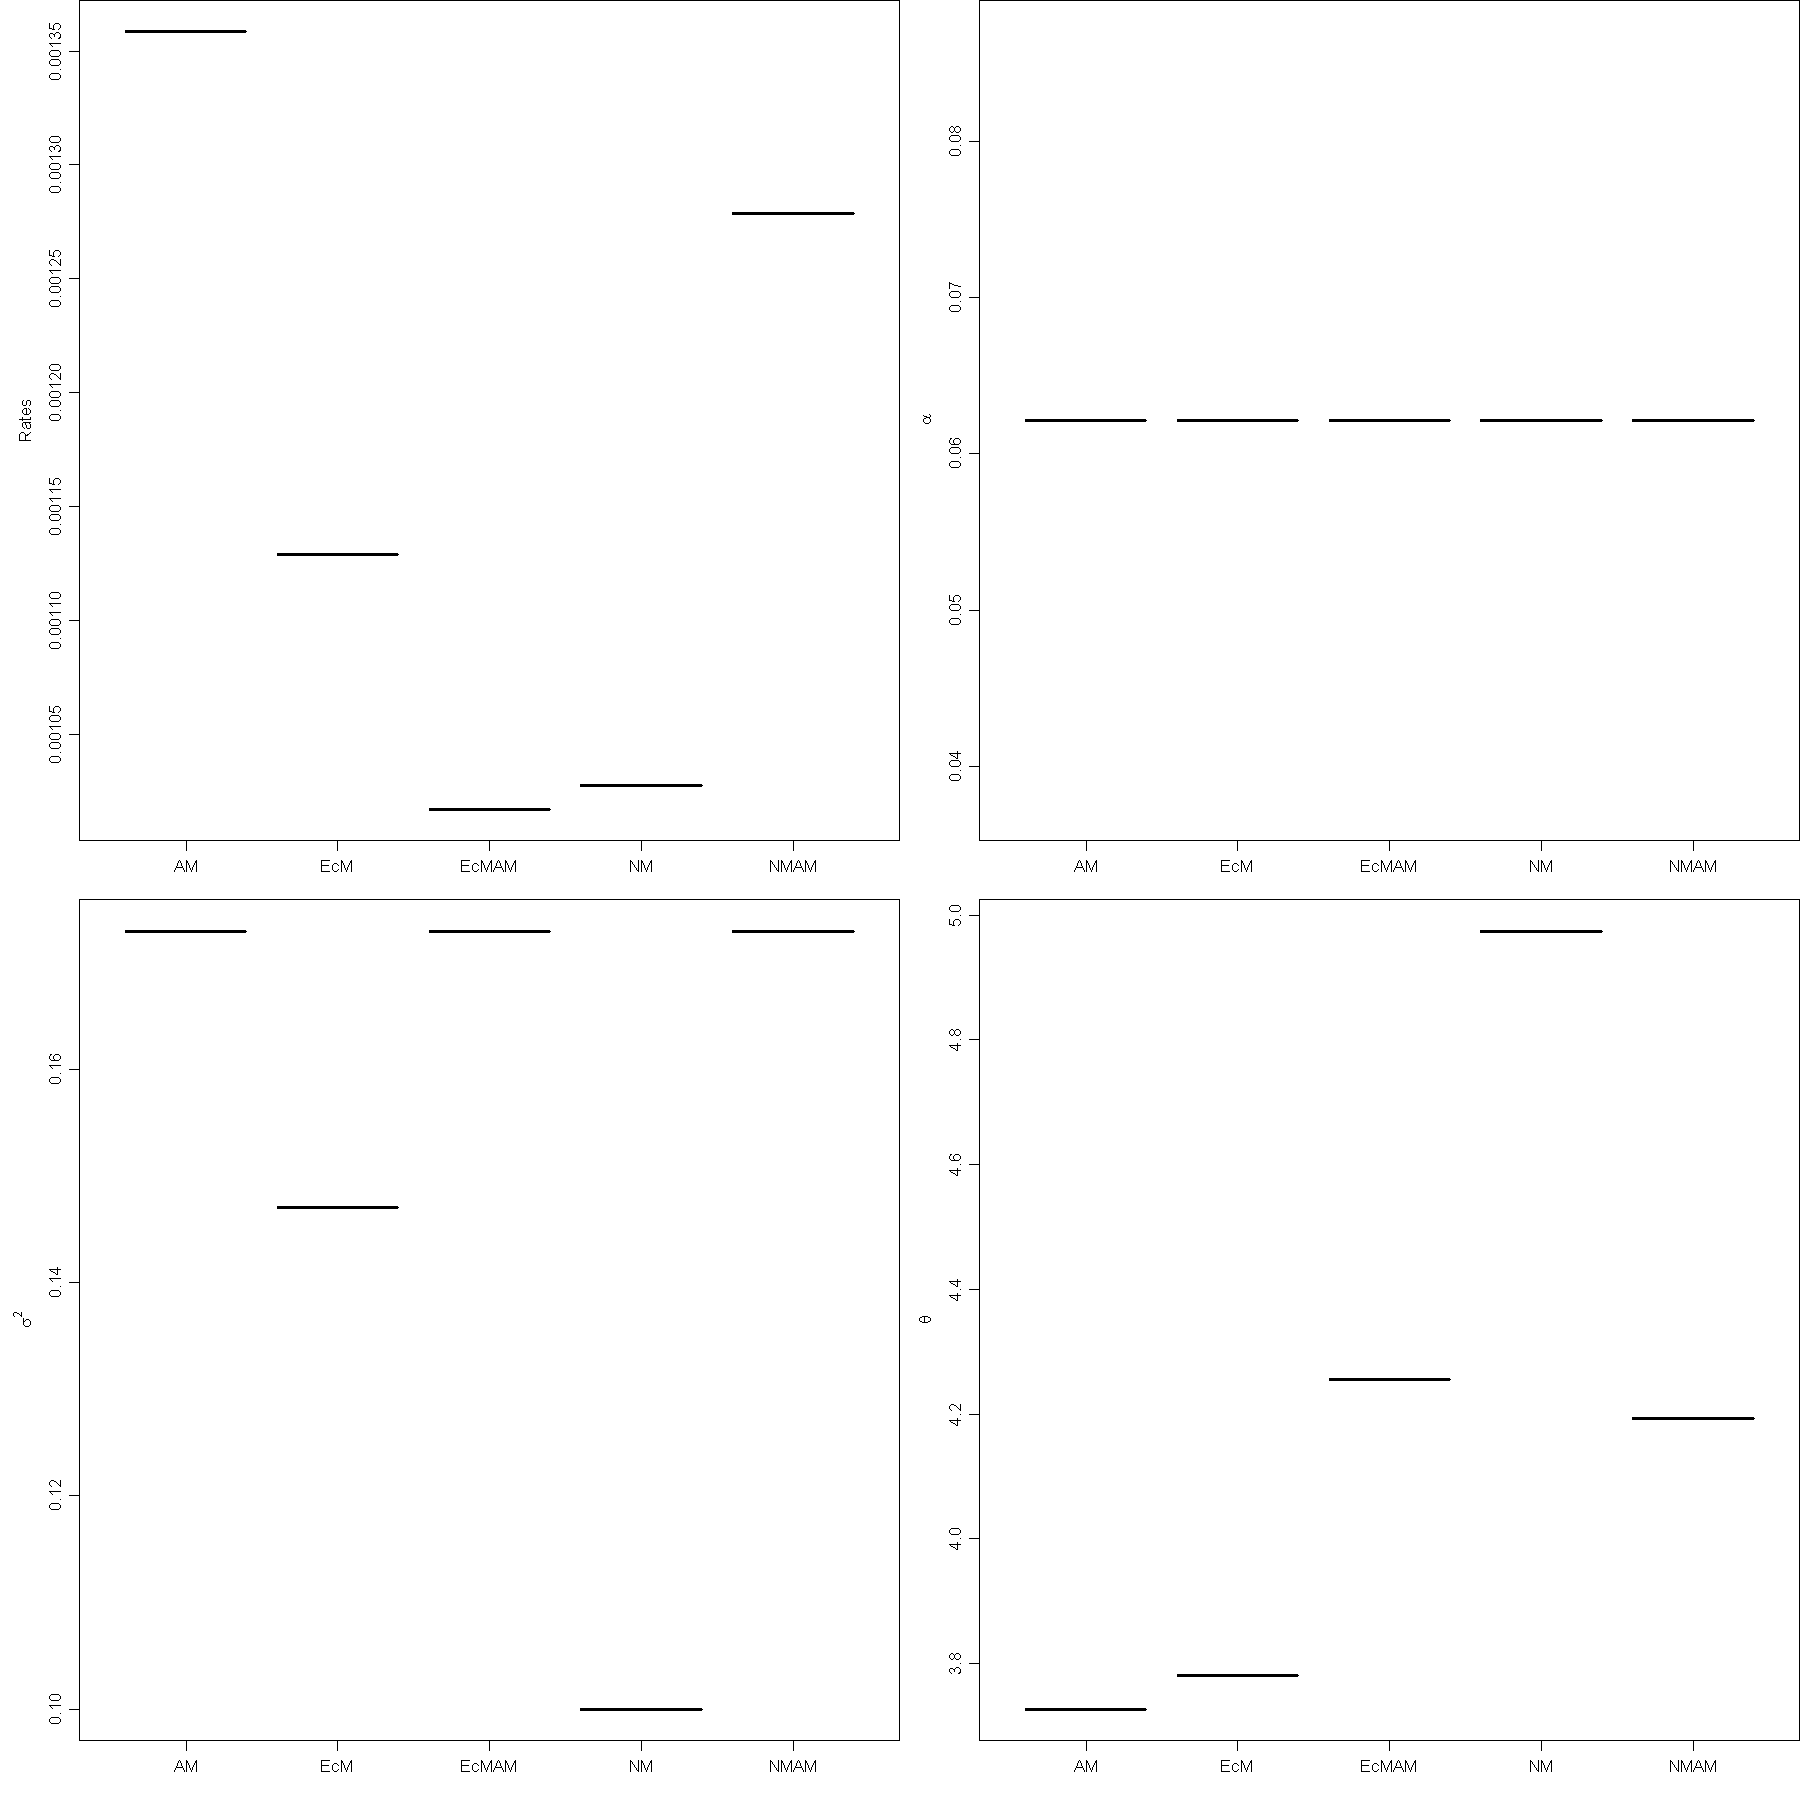

In [17]:
plot_model_averages(data = avg_srl_995_cd)

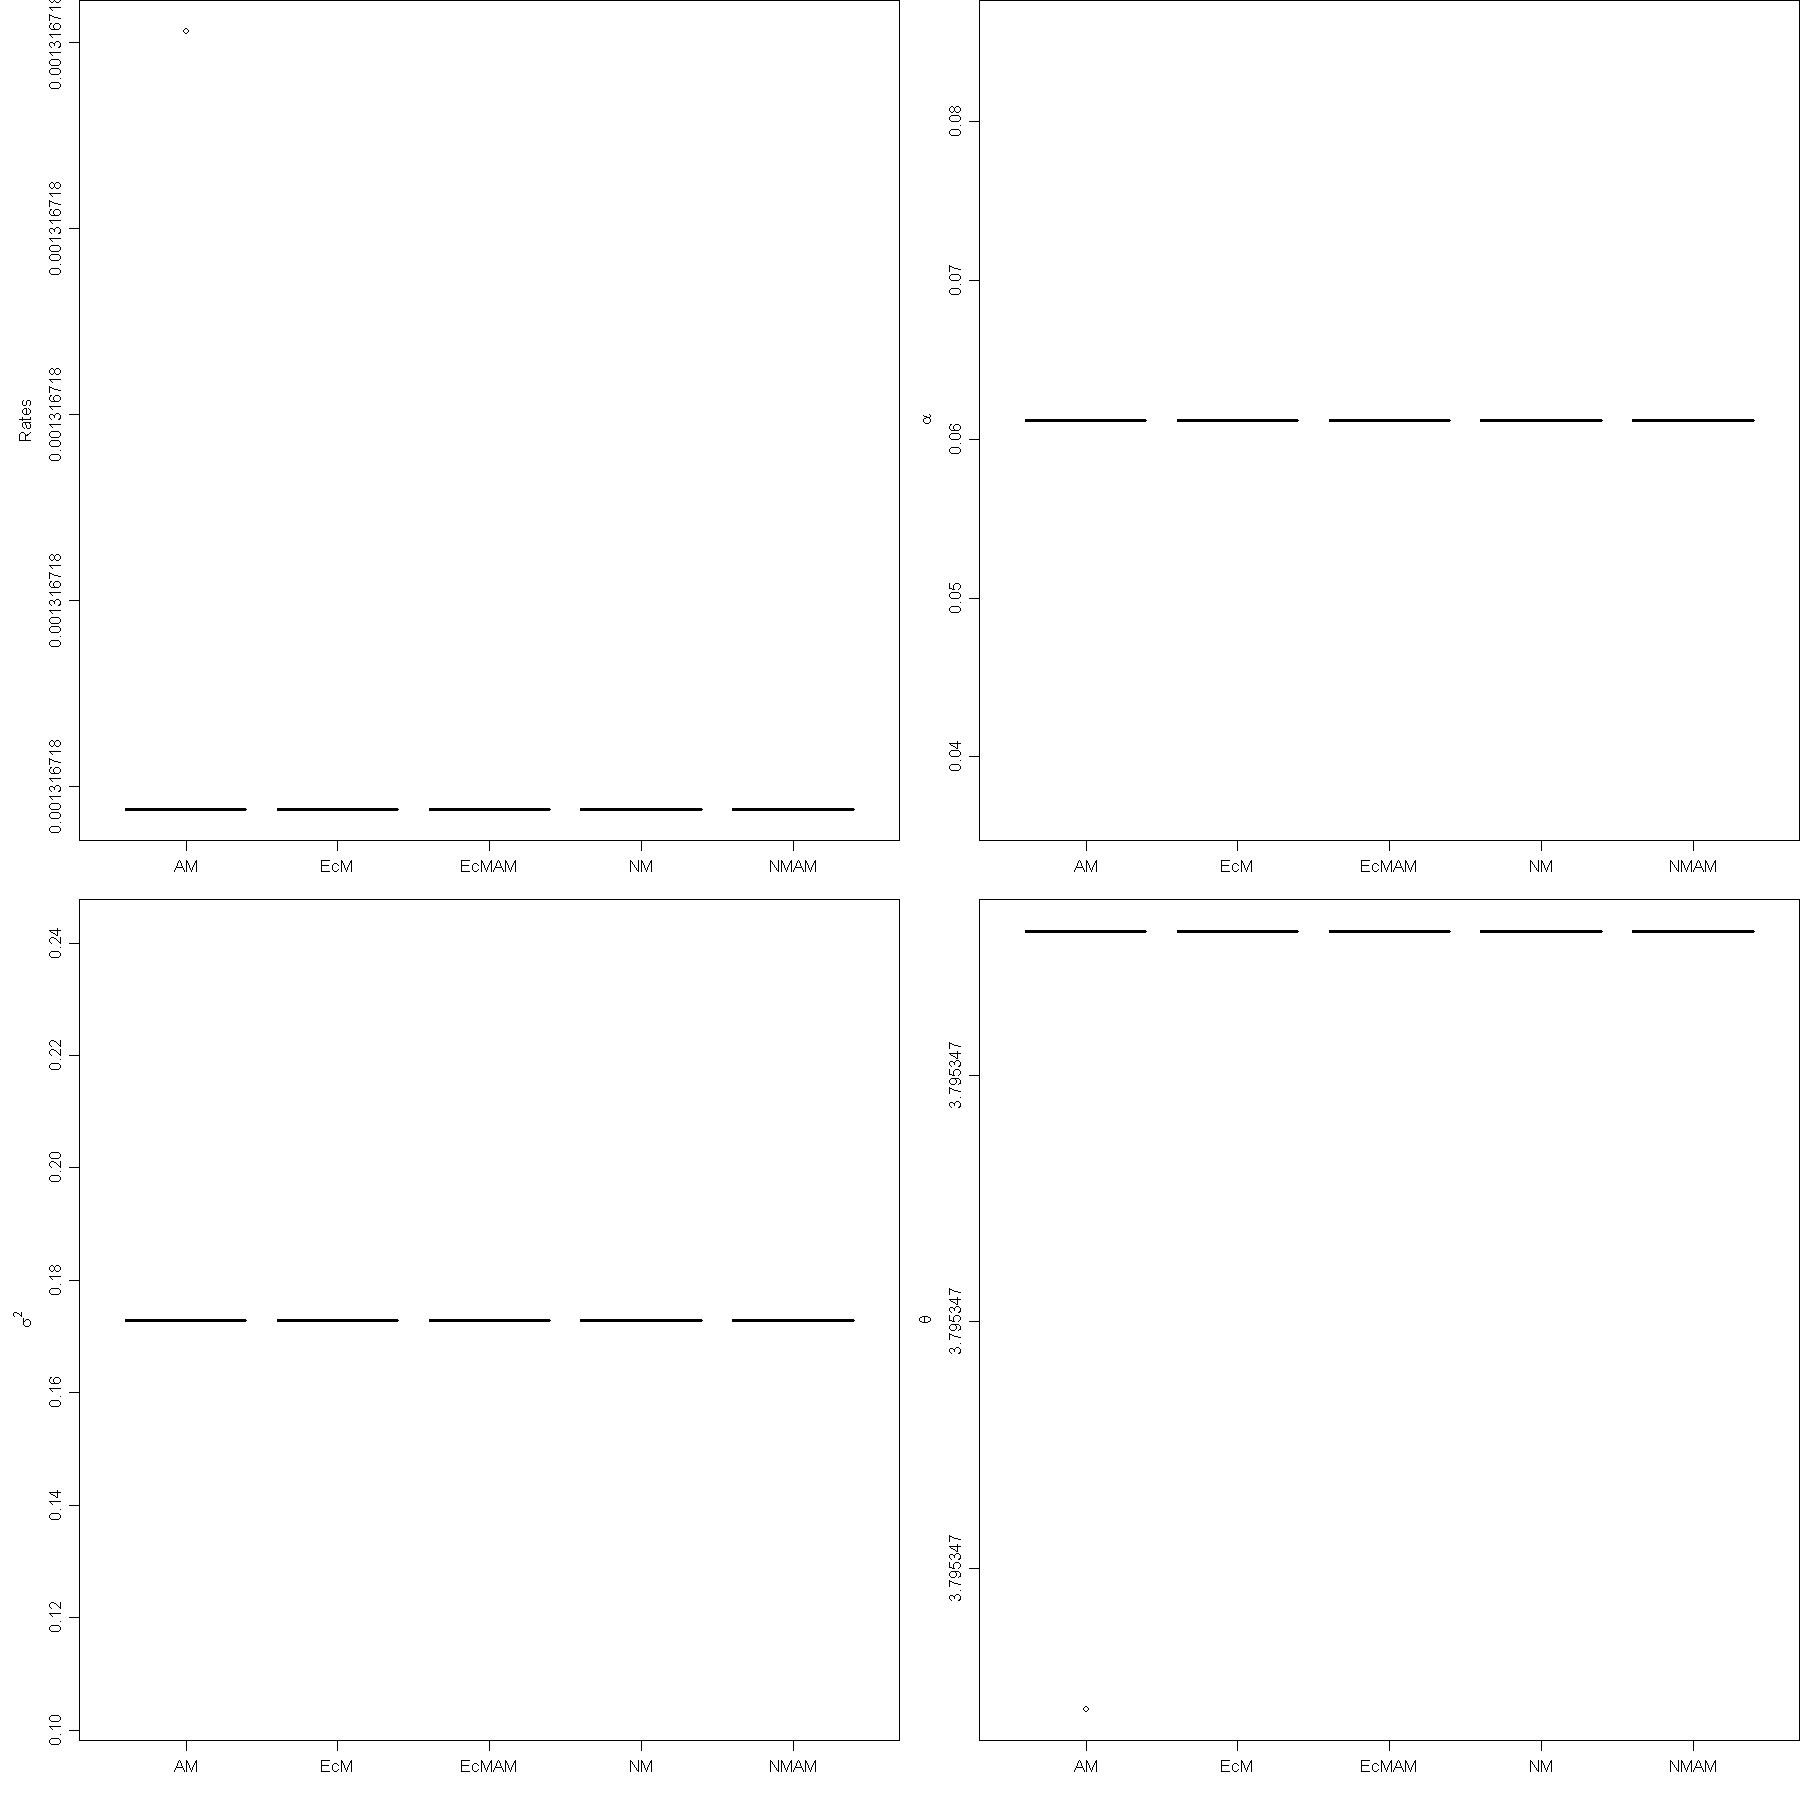

In [18]:
plot_model_averages(data = avg_srl_995_cid)

## ___2. 1292 species, 5 mycorrhizal states and FRED 4.0___
------------------------------

In [26]:
# post removal of the taxonomically conserved mycorrhizal states;
# Ericoid mycorrhizal species were removed 
# the subset had no Orchidaceous mycorrhizae, to begin with

In [22]:
#-----------------
# root diameter
#-----------------

rd_1292_cd <- read_all_rds(dirpath = "./../../data/chapter2/rdata/parallel/rd_1292_100sims/", cd = TRUE, strip = "F00679_CD")
rd_1292_cid <- read_all_rds(dirpath = "./../../data/chapter2/rdata/parallel/rd_1292_100sims/", cd = FALSE, strip = "F00679_CID")

In [23]:
OUwie::getModelTable(rd_1292_cd, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,27,-123255.19,-199.9815,-123051.35,246565.58,171311.57,0
ARDOUMA,31,-37595.22,-212.9464,-85496.09,75254.01,0.00,1
ARDOUMV,31,-123200.67,-201.5091,-122994.18,246464.92,171210.91,0
ARDOUMVA,35,-75886.77,-213.1033,-119266.61,151845.54,76591.53,0
EROUM,8,-84491.61,-214.8045,-84269.55,168999.34,93745.33,0
EROUMA,12,-56168.96,-312.9568,-62871.31,112362.17,37108.16,0
EROUMV,12,-84469.78,-213.2868,-88710.85,168963.80,93709.79,0
EROUMVA,16,-138386.88,-290.6309,-262661.63,276806.18,201552.17,0
SYMOUM,17,-83659.46,-228.0067,-84604.96,167353.40,92099.39,0


In [24]:
convergence_failures(rd_1292_cd) # 9 out of 12 models failed????

[1] "ARDOUMA"  "ARDOUMVA" "EROUM"    "EROUMA"   "EROUMV"   "SYMOUM"   "SYMOUMA" 
[8] "SYMOUMV"  "SYMOUMVA"

In [25]:
OUwie::getModelTable(rd_1292_cid, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,46,-123339.09,-238.2385,-123106.26,246773.64,171878.205,0.00000e+00
ARDOUMA,47,-37398.91,-237.7157,-73891.25,74895.44,0.000,1.00000e+00
ARDOUMV,47,-123225.33,-240.3728,-123045.39,246548.30,171652.858,0.00000e+00
ARDOUMVA,48,-42185.72,-233.2167,-77384.77,84471.21,9575.776,0.00000e+00
EROUM,8,-119511.54,-212.6618,-119294.68,239039.19,164143.753,0.00000e+00
EROUMA,9,-54116.83,-216.7180,-123160.76,108251.79,33356.352,0.00000e+00
EROUMV,9,-121872.62,-217.0078,-192994.76,243763.39,168867.949,0.00000e+00
EROUMVA,10,-38091.88,-217.0274,-101643.34,76203.92,1308.483,7.35294e-285
SYMOUM,26,-78771.41,-223.6261,-83659.39,157595.93,82700.489,0.00000e+00


In [26]:
convergence_failures(rd_1292_cid) # that's 6 out of 12 models

[1] "ARDOUMA"  "ARDOUMVA" "EROUMA"   "EROUMVA"  "SYMOUMA"  "SYMOUMVA"

In [41]:
capture.output(avg_rd_1292_cd <- OUwie::getModelAvgParams(rd_1292_cd, type = "AICc", force = FALSE), file = nullfile())
capture.output(avg_rd_1292_cid <- OUwie::getModelAvgParams(rd_1292_cid, type = "AICc", force = FALSE), file = nullfile())

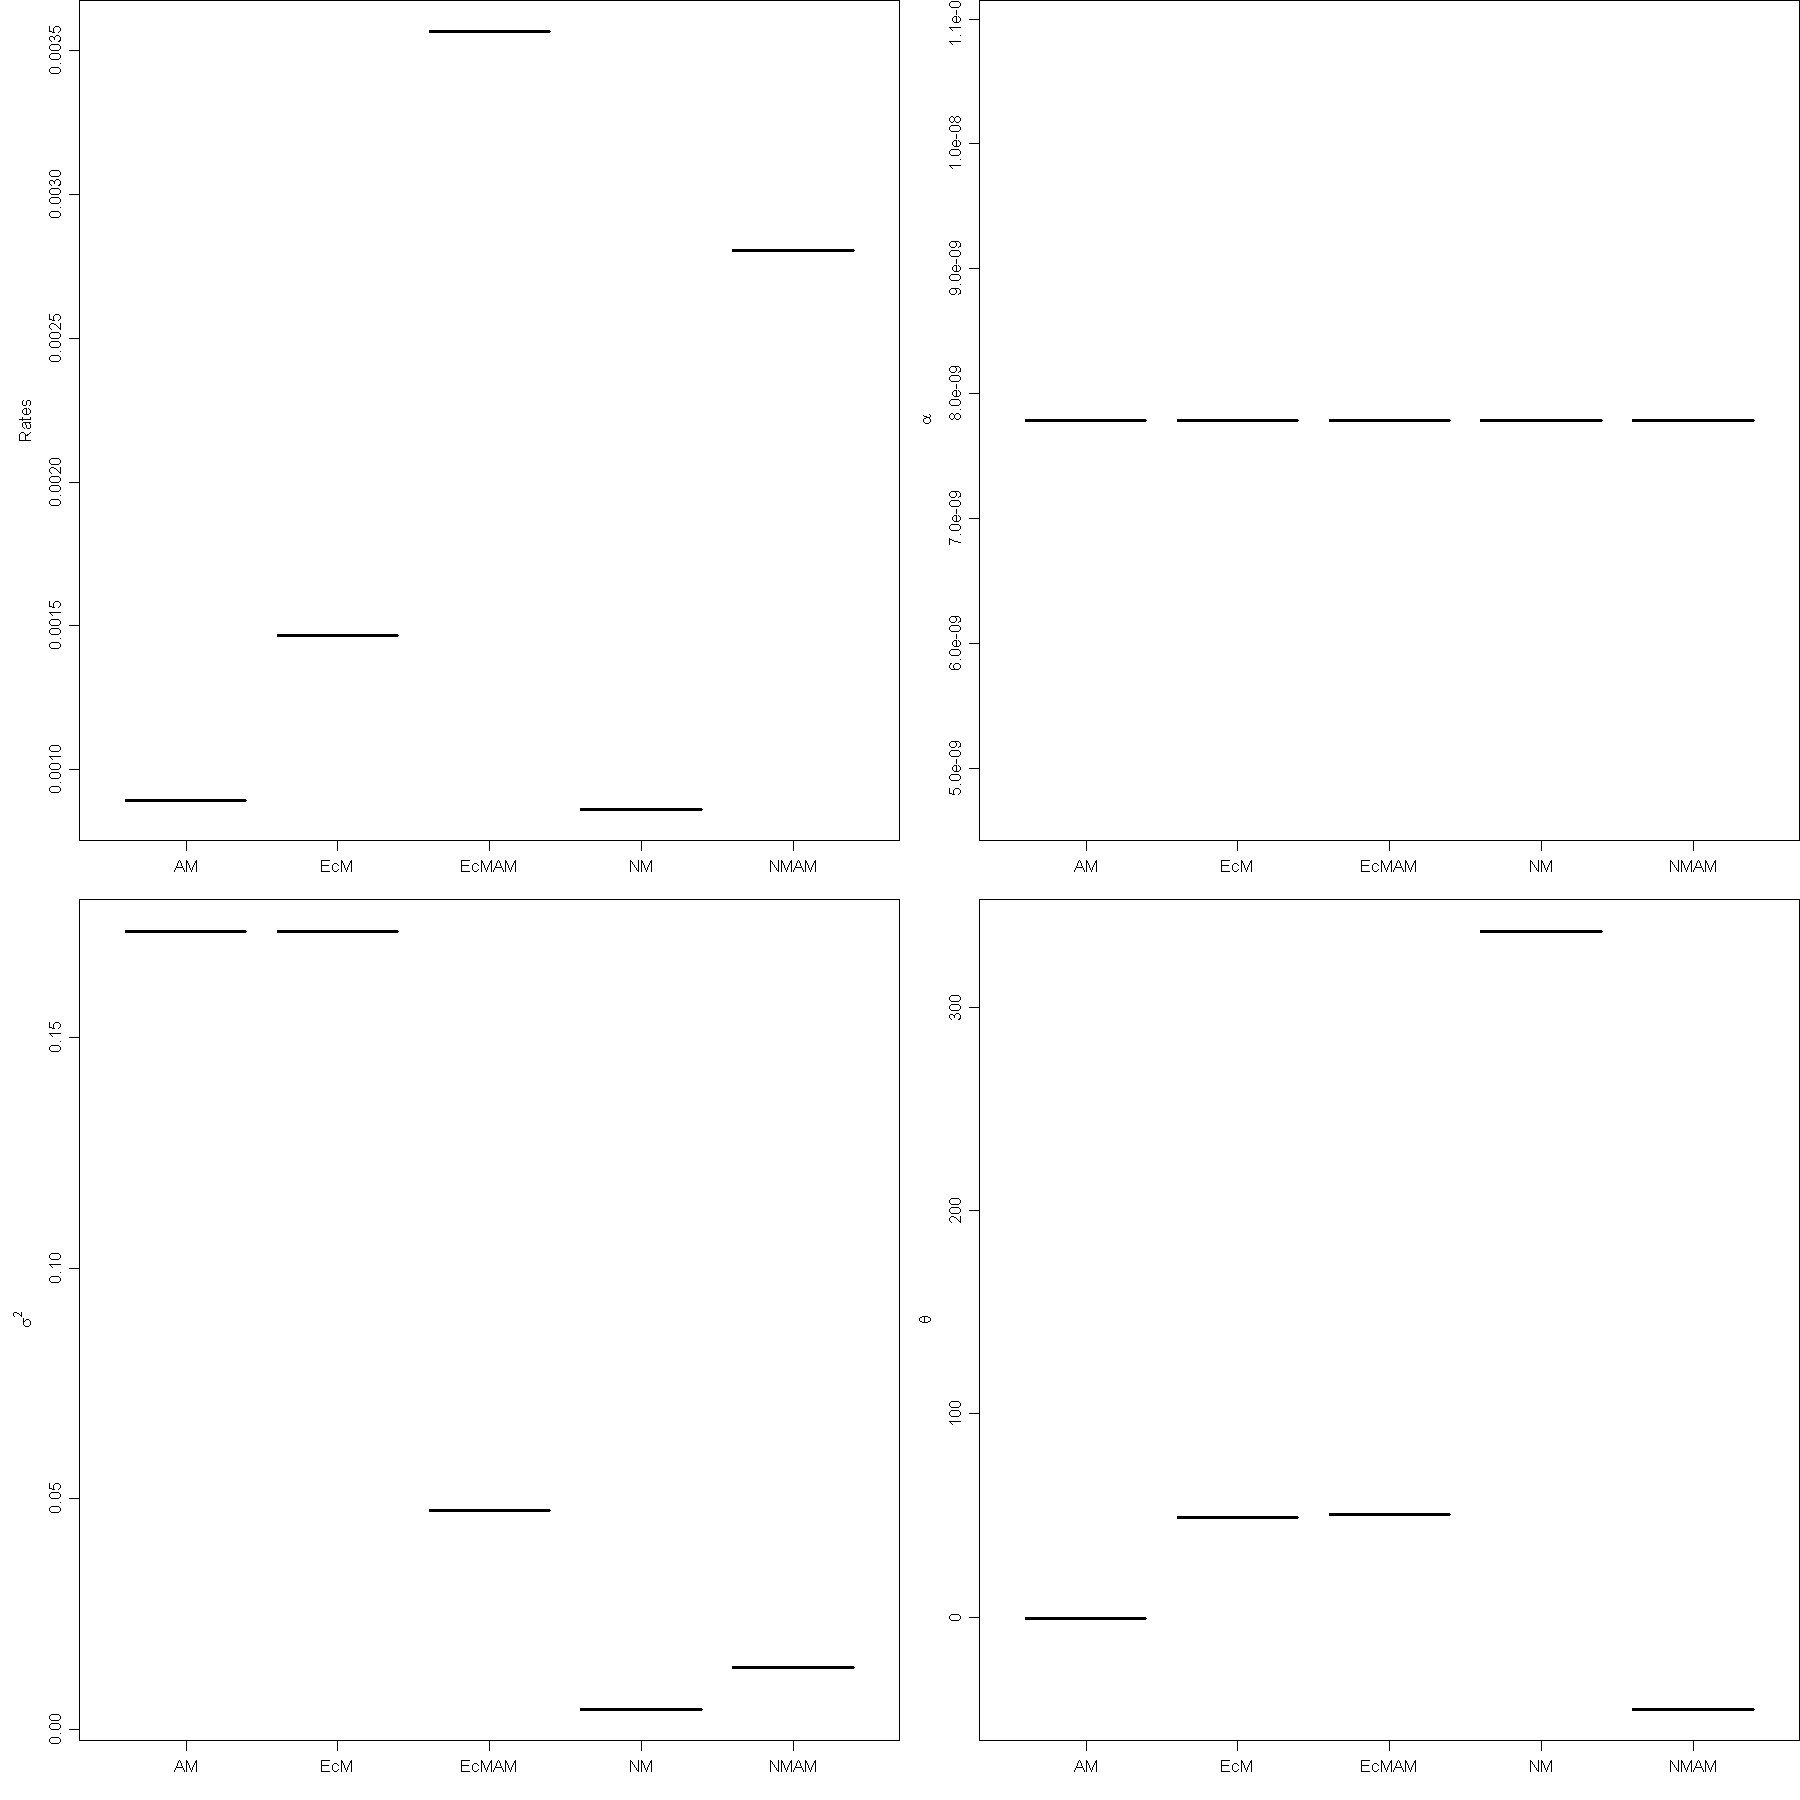

In [42]:
plot_model_averages(data = avg_rd_1292_cd)

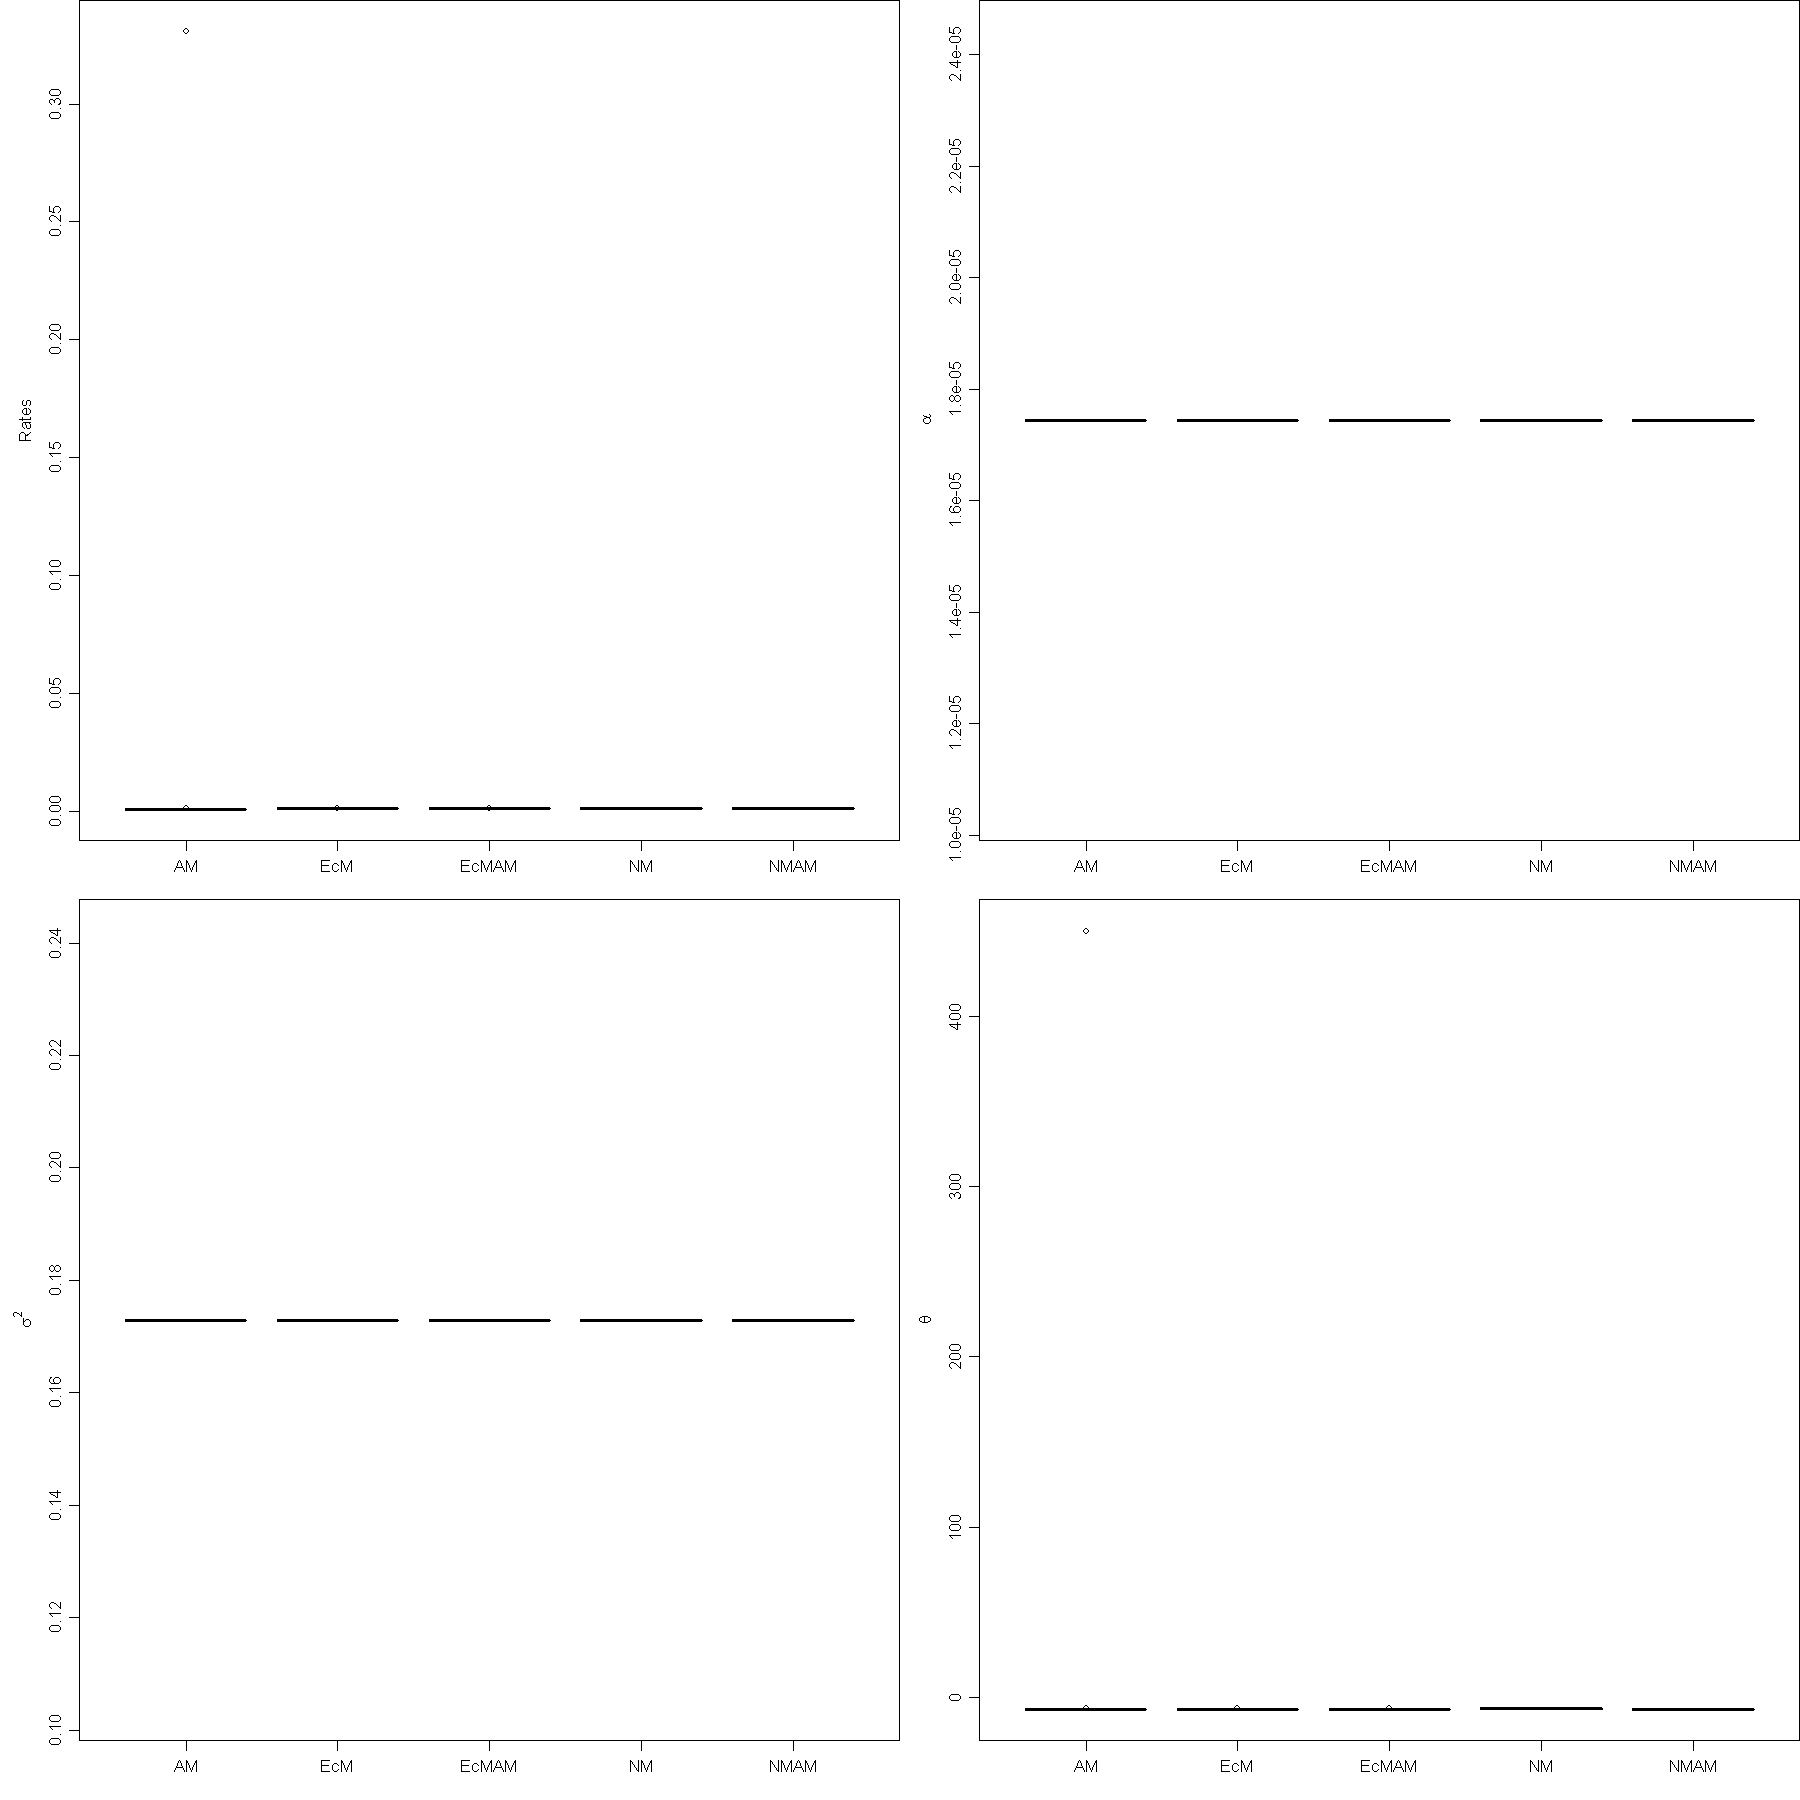

In [43]:
plot_model_averages(data = avg_rd_1292_cid)

# ___Parameter Tuning___
---------------------

In [9]:
# inspect the old hOUwie fits to optimize future fits

models_cd <- read_all_rds("../../data/chapter2/rdata/parallel/rd_1301_100sims/", cd = TRUE, strip = "_F00679_CD")
models_cid <- read_all_rds("../../data/chapter2/rdata/parallel/rd_1301_100sims/", cd = FALSE, strip = "_F00679_CID")

In [12]:
model <- readRDS("../../data/chapter2/rdata/parallel/rd_1301_100sims/SYMOUMA_F00679_CID.Rds")

# https://github.com/thej022214/OUwie/blob/master/R/hOUwie.R#L110
setNames(model$ub_continuous_model, nm = c("alpha", "sigma", "theta")) # bounds of the continuous trait are in the following order - c(lb.alpha,lb.sigma,lb.optim)

alpha       sigma       theta 
  0.1729462   0.1729462 499.9899950

In [13]:
model$ub_discrete_model

[1] 24.95087

In [14]:
model$lb_continuous_model

[1] 0.0000000001 0.0000000001 4.7450490827

In [15]:
model$lb_discrete_model

[1] 2.495087e-07

In [16]:
model$solution.cont

,(1A),(2A),(3A),(4A),(5A),(6A),(1B),(2B),(3B),(4B),(5B),(6B)
alpha,0.009615693,0.009615693,0.009615693,0.009615693,0.009615693,0.009615693,2.229048e-05,2.229048e-05,2.229048e-05,2.229048e-05,2.229048e-05,2.229048e-05
sigma2,0.172946239,0.172946239,0.172946239,0.172946239,0.172946239,0.172946239,1.729462e-01,1.729462e-01,1.729462e-01,1.729462e-01,1.729462e-01,1.729462e-01
theta,-45.254950917,-45.254950917,-45.254950917,-45.254950917,-45.254950917,-45.254950917,1.079381e+02,1.079381e+02,1.079381e+02,1.079381e+02,1.079381e+02,1.079381e+02


In [18]:
apply(model$solution.cont, MARGIN = 1, FUN = min)

alpha        sigma2         theta 
 2.229048e-05  1.729462e-01 -4.525495e+01

In [109]:
# upper and lower bounds of discrete and continuous models
# everything looks identical (these are defaults?? - not model estimated parameters!!!)

mapply(models_cd, FUN = function(x) list(UBC = x$ub_continuous_model, LBC = x$lb_continuous_model, UBD = x$ub_discrete_model, LBD = x$lb_discrete_model)) |> t() |> as.data.frame()

,UBC,LBC,UBD,LBD
,<named list>,<named list>,<named list>,<named list>
ARDOUM,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
ARDOUMA,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
ARDOUMV,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
ARDOUMVA,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
EROUM,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
EROUMA,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
EROUMV,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
EROUMVA,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
SYMOUM,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07


In [81]:
mapply(models_cid, FUN = function(x) list(UBC = x$ub_continuous_model, LBC = x$lb_continuous_model, UBD = x$ub_discrete_model, LBD = x$lb_discrete_model)) |> t() |> as.data.frame()

,UBC,LBC,UBD,LBD
,<named list>,<named list>,<named list>,<named list>
ARDOUM,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
ARDOUMA,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
ARDOUMV,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
ARDOUMVA,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
EROUM,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
EROUMA,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
EROUMV,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
EROUMVA,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
SYMOUM,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07


In [89]:
# transition rates

mapply(models_cd, FUN = function(x) list(dmax = max(x$solution.disc, na.rm = TRUE), dmin = min(x$solution.disc, na.rm = TRUE))) |> t() |> as.data.frame()

,dmax,dmin
,<named list>,<named list>
ARDOUM,0.006338935,1.373761e-06
ARDOUMA,0.0002656235,8.090315e-06
ARDOUMV,0.004001858,1.182816e-05
ARDOUMVA,0.0002656235,8.66839e-06
EROUM,0.0002238004,0.0002238004
EROUMA,6.801639,6.801639
EROUMV,0.0002022754,0.0002022754
EROUMVA,0.008399754,0.008399754
SYMOUM,0.0007361478,4.140943e-07


In [92]:
mapply(models_cid, FUN = function(x) list(dmax = max(x$solution.disc, na.rm = TRUE), dmin = min(x$solution.disc, na.rm = TRUE))) |> t() |> as.data.frame()

,dmax,dmin
,<named list>,<named list>
ARDOUM,0.0003752032,0.0001675971
ARDOUMA,0.0002656235,4.723529e-05
ARDOUMV,0.0002656235,0.0002656235
ARDOUMVA,0.02656235,0.0001214134
EROUM,0.0003812546,5.16566e-05
EROUMA,0.01278417,2.495087e-07
EROUMV,0.0007774337,8.399754e-05
EROUMVA,0.006779943,0.0002656235
SYMOUM,0.000336724,5.972368e-06


In [1]:
# for continuous models the sequence is c(alpha, sigma, theta)

In [24]:
# CD fits - continuous model params - maxes

mapply(models_cd, FUN = function(x) apply(x$solution.cont, MARGIN = 1, FUN = max, na.rm = TRUE)) # this returns the max of each params for different states within each fits

,ARDOUM,ARDOUMA,ARDOUMV,ARDOUMVA,EROUM,EROUMA,EROUMV,EROUMVA,SYMOUM,SYMOUMA,SYMOUMV,SYMOUMVA
alpha,2.738273e-07,0.02175001,5.848399e-09,0.02175001,1.047976e-10,0.04528611,1.060156e-10,0.01961547,1.476953e-10,2.118098e-03,1.399549e-10,0.06060018
sigma2,1.729462e-01,0.17294624,1.729462e-01,0.05469040,1.729462e-01,0.17294624,1.729462e-01,0.17294624,1.729462e-01,1.729462e-01,1.729462e-01,0.17294624
theta,4.499900e+02,-0.91082740,4.499900e+02,0.98686036,1.940909e+02,3.18866445,3.251291e+02,107.27723423,1.074415e+02,1.559061e+02,1.421200e+02,125.05260777


In [27]:
mapply(models_cd, FUN = function(x) apply(x$solution.cont, MARGIN = 1, FUN = max, na.rm = TRUE)) |> apply(FUN = max, MARGIN = 1) # max across all the fits

alpha       sigma2        theta 
  0.06060018   0.17294624 449.98999500

In [28]:
mapply(models_cd, FUN = function(x) apply(x$solution.cont, MARGIN = 1, FUN = min, na.rm = TRUE)) |> apply(FUN = min, MARGIN = 1) # min across all the fits

alpha        sigma2         theta 
 1.000000e-10  1.355719e-06 -4.525495e+01

In [30]:
# CID fits

mapply(models_cid, FUN = function(x) apply(x$solution.cont, MARGIN = 1, FUN = max, na.rm = TRUE))

,ARDOUM,ARDOUMA,ARDOUMV,ARDOUMVA,EROUM,EROUMA,EROUMV,EROUMVA,SYMOUM,SYMOUMA,SYMOUMV,SYMOUMVA
alpha,7.289750e-05,0.01457781,5.469040e-08,0.02059171,5.442531e-05,5.469040e-05,5.469040e-05,5.472754e-05,1.766810e-05,9.615693e-03,7.100862e-09,9.725482e-03
sigma2,1.729462e-01,0.17294624,1.729462e-01,0.17294624,1.729462e-01,1.729462e-01,1.729462e-01,1.729462e-01,1.729462e-01,1.729462e-01,1.729462e-01,1.729462e-01
theta,1.126031e+02,98.57260218,1.079381e+02,107.93811043,1.574389e+02,1.645572e+02,1.205584e+02,1.051561e+02,4.499900e+02,1.079381e+02,1.236215e+02,1.079381e+02


In [31]:
mapply(models_cid, FUN = function(x) apply(x$solution.cont, MARGIN = 1, FUN = max, na.rm = TRUE)) |> apply(FUN = max, MARGIN = 1) # max across all the fits

alpha       sigma2        theta 
  0.02059171   0.17294624 449.98999500

In [32]:
mapply(models_cid, FUN = function(x) apply(x$solution.cont, MARGIN = 1, FUN = min, na.rm = TRUE)) |> apply(FUN = min, MARGIN = 1) # min across all the fits

alpha        sigma2         theta 
 7.100862e-09  7.293082e-04 -4.525495e+01

# ___1301 species, 6 states and FRED 4.0___
---------------------------

In [9]:
#----------------
# root diameter
#----------------

rd_models_cd <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/F00679/", cd = TRUE, strip = "_F00679_CD_250")
rd_models_cid <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/F00679/", cd = FALSE, strip = "_F00679_CID_250")

avg_rd_1301_cd <- getModelAvgParams_patched(rd_models_cd, type = "AICc", force = FALSE)
avg_rd_1301_cid <- getModelAvgParams_patched(rd_models_cid, type = "AICc", force = FALSE)

In [8]:
#--------------------------
# specific root length
#--------------------------

srl_models_cd <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/F00727/", cd = TRUE, strip = "_F00727_CD_250")
srl_models_cid <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/F00727/", cd = FALSE, strip = "_F00727_CID_250")

# capture.output(avg_srl_1301_cd <- OUwie::getModelAvgParams(srl_models_cd, type = "AICc"), file = nullfile())
# capture.output(avg_srl_1301_cid <- OUwie::getModelAvgParams(srl_models_cid, type = "AICc"), file = nullfile())

In [19]:
#--------------------------
# root tissue density
#--------------------------

rtd_models_cd <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/F00709/", cd = TRUE, strip = "_F00709_CD_250")
rtd_models_cid <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/F00709/", cd = FALSE, strip = "_F00709_CID_250")

# setting force = FALSE for CD models since it emitted a warning about potentially failed models
# capture.output(avg_rtd_1301_cd <- OUwie::getModelAvgParams(rtd_models_cd, type = "AICc", force = FALSE), file = nullfile())
# capture.output(avg_rtd_1301_cid <- OUwie::getModelAvgParams(rtd_models_cid, type = "AICc"), file = nullfile())

In [ ]:
# let's do the plotting with Python - this R shit sucks

In [40]:
OUwie::getModelTable(rd_models_cd, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,38,-78244.22,-228.6161,-82956.447,156566.78,129654.769,0
ARDOUMA,43,-112461.06,-224.3190,-129766.953,225011.14,198099.123,0
ARDOUMV,43,-510516.56,-222.0081,-510280.266,1021122.13,994210.116,0
ARDOUMVA,48,-2398522.25,-231.5829,-11645497.119,4797144.25,4770232.240,0
EROUM,9,-196104.06,-225.8448,-195873.341,392226.26,365314.252,0
EROUMA,14,-300345.82,-1884.1890,-1850545.883,600719.97,573807.953,0
EROUMV,14,-78597.10,-225.8553,-78366.580,157222.52,130310.511,0
EROUMVA,19,-19861.75,-3639.9567,-191084.017,39762.09,12850.079,0
SYMOUM,23,-148446.07,-210.1108,-148230.986,296939.01,270026.993,0


In [34]:
OUwie::getModelTable(rd_models_cid, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,66,-110586.589,-255.1753,-110334.947,221312.34,208582.4252,0.000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
ARDOUMA,67,-23105.467,-252.8371,-77626.332,46352.32,33622.4039,0.000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
ARDOUMV,67,-120896.763,-253.4864,-120646.280,241934.92,229204.9964,0.000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
ARDOUMVA,68,-6293.151,-251.7261,-7860.832,12729.92,0.0000,1.000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
EROUM,8,-360875.236,-225.8432,-360643.922,721766.58,709036.6637,0.000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
EROUMA,9,-9361.830,-1991.7985,-39163.976,18741.80,6011.8794,0.000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
EROUMV,9,-173440.330,-883.4908,-231222.738,346898.80,334168.8801,0.000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
EROUMVA,10,-6602.231,-303.3245,-220165.152,13224.63,494.7128,0.000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000003753799
SYMOUM,36,-173323.051,-239.3740,-173079.025,346720.21,333990.2903,0.000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000


In [35]:
OUwie::getModelTable(srl_models_cd, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,38,-910644.14,-210.6293,-910428.052,1821366.64,1790470.49,0
ARDOUMA,43,-23900.90,-229.6771,-46608.560,47890.81,16994.66,0
ARDOUMV,43,-2505246.29,-205.4940,-2505035.380,5010581.59,4979685.44,0
ARDOUMVA,48,-378318.42,-222.5758,-653767.890,756736.59,725840.44,0
EROUM,9,-1177996.74,-225.8349,-1177765.978,2356011.61,2325115.46,0
EROUMA,14,-15433.91,-259.5788,-7241.631,30896.15,0.00,1
EROUMV,14,-64856.53,-225.8251,-64625.923,129741.38,98845.23,0
EROUMVA,19,-1452537.47,-3651.3023,-14529754.859,2905113.54,2874217.39,0
SYMOUM,23,-364346.74,-210.0764,-364131.181,728740.34,697844.19,0


In [36]:
OUwie::getModelTable(srl_models_cid, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,66,-1775031.779,-251.4615,-1774778.583,3550202.73,3535003.9653,0.0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
ARDOUMA,67,-7528.685,-250.8890,-7236.270,15198.76,0.0000,1.0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
ARDOUMV,67,-2067202.650,-251.5637,-2066942.929,4134546.69,4119347.9289,0.0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
ARDOUMVA,68,-7742.486,-248.0524,-7719.972,15628.59,429.8281,0.0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000004613425
EROUM,8,-1049013.177,-225.8267,-1048781.856,2098042.47,2082843.7046,0.0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
EROUMA,9,-14949.875,-709.0572,-43967.928,29917.89,14719.1293,0.0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
EROUMV,9,-1412312.595,-226.9141,-1412073.088,2824643.33,2809444.5685,0.0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
EROUMVA,10,-37005.104,-666.1275,-159579.154,74030.38,58831.6189,0.0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
SYMOUM,36,-428200.383,-244.2427,-427954.748,856474.87,841276.1130,0.0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000


In [37]:
options("digits" = 7)
options(scipen=999)

In [38]:
OUwie::getModelTable(rtd_models_cd, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,38,-602570.34,-205.3885,-602359.49,1205219.02,18347974422,0
ARDOUMA,43,-20812.30,-230.0388,-14130.16,41713.61,18346810917,0
ARDOUMV,43,-305412.12,-220.3118,-305184.40,610913.25,18347380116,0
ARDOUMVA,48,-1531492.48,-227.5947,-3666292.67,3063084.71,18349832288,0
EROUM,9,-377836.12,-227.4567,-377596.54,755690.38,18347524893,0
EROUMA,14,-11239.27,-2477.5975,-14687.03,22506.86,18346791710,0
EROUMV,14,-452265.75,-392.0750,-450470.96,904559.84,18347673763,0
EROUMVA,19,-11765.02,-4103.5318,-16228.12,23568.64,18346792772,0
SYMOUM,23,-164904.99,-209.9689,-164690.07,329856.84,18347099060,0


In [39]:
OUwie::getModelTable(rtd_models_cid, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,66,-273787.802,-261.0782,-273538.962,547714.77,533680.769,0.000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
ARDOUMA,67,-238252.794,-253.0621,-996766.810,476646.98,462612.977,0.000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
ARDOUMV,67,-598063.728,-246.7412,-597840.252,1196268.85,1182234.844,0.000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
ARDOUMVA,68,-7606.784,-252.9604,-7430.333,15357.18,1323.183,0.000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000004726592
EROUM,8,-430697.243,-225.8774,-430466.592,861410.60,847376.596,0.000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
EROUMA,9,-7105.815,-407.3368,-7008.007,14229.77,195.767,0.000000000000000000000000000000000000000000308844236268225127766892668113030140375485643744468688964843750000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
EROUMV,9,-41256.582,-225.8478,-41025.241,82531.30,68497.301,0.000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
EROUMVA,10,-10069.976,-637.1333,-21927.752,20160.12,6126.122,0.000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
SYMOUM,36,-165979.960,-244.1117,-226282.799,332034.03,318000.026,0.000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000


## ___`houwie-update`___
---------------------------

In [ ]:
# https://github.com/thej022214/OUwie/tree/houwie-update

In [12]:
# total runtime

# RD
(9840.27344 + 16980.49199 + 21660.65702 + 40441.490212 + 40681.503229 + 48421.67138 + 48601.677552 + 49081.685838 + 56941.868809 + 61501.935362 + 62461.950735 + 62641.955987 + 62821.967265 + 67562.031103 +
110342.480784 + 110522.486358 + 110522.489042 + 110702.492794 + 110942.495852 + 111422.502127 + 111422.503425 + 111662.505903 + 111722.50821 + 111782.510831) / (60 * 60) # hours

[1] 489.0795

In [13]:
# SRL 
(24841.90748 + 29522.118913 + 31082.216431 + 40142.769026 + 51843.104812 + 57423.160672 + 62103.248476 + 66363.303821 + 66543.307467 + 68703.373037 + 70263.394198 + 70503.39939 +
72963.424265 + 73083.430351 + 73203.436505 + 73623.463346 + 81183.543111 + 120304.087131 + 120844.099333 + 121144.103509 + 121384.105664 + 121624.108189 + 121684.109727 + 122284.114825) / (60 * 60)

[1] 517.4059

In [ ]:
# RTD
()

In [14]:
489.079482013333 + 517.405924910833

[1] 1006.485

In [8]:
rd_new_cd <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/houwie-update/RD/", cd = TRUE, strip = "_F00679_CD_100")
rd_new_cid <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/houwie-update/RD/", cd = FALSE, strip = "_F00679_CID_100")

In [13]:
OUwie::getModelTable(rd_new_cd, type = "AICc") # this looks great :))))

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,38,-1010.270,-204.2927,-798.6367,2098.888,34.624896,2.910347e-08
ARDOUMA,43,-1005.471,-205.1237,-793.4270,2099.952,35.689324,1.709256e-08
ARDOUMV,43,-1007.558,-204.5516,-797.7127,2104.127,39.864290,2.119458e-09
ARDOUMVA,48,-1003.788,-204.8559,-792.8556,2107.334,43.071096,4.264574e-10
EROUM,9,-1028.576,-223.7613,-795.1226,2075.291,11.027671,3.872728e-03
EROUMA,14,-1025.683,-224.2258,-793.6264,2079.693,15.430454,4.285138e-04
EROUMV,14,-1024.862,-224.4261,-792.2893,2078.052,13.788505,9.738891e-04
EROUMVA,19,-1012.835,-224.2323,-780.6175,2064.263,0.000000,9.608274e-01
SYMOUM,23,-1012.714,-207.8091,-796.3740,2072.293,8.030229,1.733418e-02


In [10]:
OUwie::getModelTable(rd_new_cid, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,66,-996.2278,-250.5429,-753.3318,2131.622,178.74853,1.531963e-39
ARDOUMA,67,-1020.9135,-487.8563,-725.0186,2183.217,230.34315,9.585612e-51
ARDOUMV,67,-1024.9819,-323.0189,-716.3393,2191.354,238.48002,1.639537e-52
ARDOUMVA,68,-1017.9832,-226.4809,-777.8426,2179.583,226.70942,5.897594e-50
EROUM,8,-981.6118,-367.8199,-684.4236,1979.335,26.46103,1.794984e-06
EROUMA,9,-1012.3366,-366.6254,-711.4832,2042.813,89.93860,2.951755e-20
EROUMV,9,-989.5762,-526.7730,-683.9435,1997.292,44.41784,2.263536e-10
EROUMVA,10,-1000.9691,-376.8922,-718.3404,2022.109,69.23474,9.244146e-16
SYMOUM,36,-970.5243,-255.5475,-696.4220,2015.156,62.28230,2.989298e-14


In [12]:
rd_new_cd[["ARDOUMA"]]


Fit
    lnLTot   lnLDisc  lnLCont      AIC     AICc     BIC nTaxa nPars
 -1005.471 -205.1237 -793.427 2096.942 2099.952 2319.29  1301    43

Legend
      1       2       3       4       5       6 
   "AM"   "EcM" "EcMAM"   "ErM"    "NM"  "NMAM" 

Regime Rate matrix
             (1)          (2)          (3)          (4)          (5)
(1)           NA 1.381555e-04 1.278242e-04 3.505787e-05 1.196743e-04
(2) 6.821572e-04           NA 1.000000e-15 1.000000e-15 1.000000e-15
(3) 1.418982e-02 1.000000e-15           NA 1.000000e-15 1.000000e-15
(4) 1.000000e-15 4.777632e-03 1.415667e-15           NA 1.000000e-15
(5) 6.162779e-04 1.000000e-15 1.000000e-15 1.000000e-15           NA
(6) 1.723551e-03 9.895295e-04 1.000000e-15 1.000000e-15 1.000000e-15
             (6)
(1) 5.503929e-04
(2) 5.654466e-04
(3) 1.000000e-15
(4) 1.152526e-15
(5) 1.000000e-15
(6)           NA

OU Estimates
               (1)         (2)         (3)         (4)         (5)         (6)
alpha   0.17294624  0.17294624  0.1729

In [16]:
srl_new_cd <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/houwie-update/SRL/", cd = TRUE, strip = "_F00727_CD_100")
srl_new_cid <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/houwie-update/SRL/", cd = FALSE, strip = "_F00727_CID_100")

In [17]:
OUwie::getModelTable(srl_new_cd, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,38,-2289.800,-204.7249,-2077.563,4657.949,23.5624555,2.983142e-06
ARDOUMA,43,-2284.300,-205.0339,-2070.401,4657.611,23.2248490,3.531703e-06
ARDOUMV,43,-2285.183,-204.9484,-2076.012,4659.377,24.9905889,1.460692e-06
ARDOUMVA,48,-2284.385,-205.3292,-2072.013,4668.528,34.1416139,1.504662e-08
EROUM,9,-2309.949,-223.9789,-2079.684,4638.037,3.6512844,6.285354e-02
EROUMA,14,-2305.174,-224.3805,-2074.767,4638.675,4.2893312,4.568563e-02
EROUMV,14,-2305.945,-224.4289,-2075.341,4640.217,5.8312388,2.113288e-02
EROUMVA,19,-2301.900,-224.1698,-2071.315,4642.393,8.0064163,7.122376e-03
SYMOUM,23,-2294.020,-207.1925,-2079.124,4634.904,0.5182975,3.010574e-01


In [18]:
OUwie::getModelTable(srl_new_cid, type = "AICc") # interesting

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,66,-2747.992,-231.0784,-2539.280,5635.152,1063.44479,1.190962e-231
ARDOUMA,67,-2337.879,-418.9557,-2066.624,4817.148,245.44151,5.047232e-54
ARDOUMV,67,-2369.040,-352.9374,-2128.832,4879.470,307.76324,1.479319e-67
ARDOUMVA,68,-2346.543,-248.1520,-2077.249,4836.704,264.99686,2.861952e-58
EROUM,8,-2339.338,-224.1813,-2109.070,4694.788,123.08090,1.876389e-27
EROUMA,9,-2328.390,-223.7516,-2098.097,4674.920,103.21332,3.868230e-23
EROUMV,9,-2327.469,-559.8723,-1993.739,4673.078,101.37120,9.716792e-23
EROUMVA,10,-2328.512,-223.6507,-2098.217,4677.195,105.48769,1.240618e-23
SYMOUM,36,-2309.256,-235.3004,-2083.201,4692.620,120.91262,5.548265e-27


## ___Fine root subset comparison___
--------------------

In [7]:
# root diameter <= 2.00 mm subset
cd_diamater_rd <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/fineroots-comp/F00679D/", cd = TRUE, strip = "_F00679D_CD_200") # CD fits
cid_diamater_rd <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/fineroots-comp/F00679D/", cd = FALSE, strip = "_F00679D_CID_200") # CID fits

# root order <= 3 subset
cd_order_rd <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/fineroots-comp/F00679O/", cd = TRUE, strip = "_F00679O_CD_200") # CD fits
cid_order_rd <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/fineroots-comp/F00679O/", cd = FALSE, strip = "_F00679O_CID_200") # CID fits

In [19]:
OUwie::getModelTable(cd_diamater_rd, type = "AICc")["AICc"] |> t() # lowest is EROUMA - 1195.924

,ARDOUM,ARDOUMA,ARDOUMV,ARDOUMVA,EROUM,EROUMA,EROUMV,EROUMVA,SYMOUM,SYMOUMA,SYMOUMV,SYMOUMVA
AICc,1359.014,2787.785,1318.745,4316.879,4171.651,1195.924,10650.3,15541.25,1344.107,5975.95,41352.25,10140.35


In [20]:
OUwie::getModelTable(cid_diamater_rd, type = "AICc")["AICc"] |> t() # lowest is EROUMV - 1207.401

,ARDOUM,ARDOUMA,ARDOUMV,ARDOUMVA,EROUM,EROUMA,EROUMV,EROUMVA,SYMOUM,SYMOUMA,SYMOUMV,SYMOUMVA
AICc,30713.65,1340.778,285009.2,57828.27,490695.1,1532.076,1207.401,2057.695,1294.351,2509.911,12632.29,2429.756


In [23]:
OUwie::getModelTable(cd_order_rd, type = "AICc")["AICc"] |> t() # lowest is ARDOUM - 1046.341417652

,ARDOUM,ARDOUMA,ARDOUMV,ARDOUMVA,EROUM,EROUMA,EROUMV,EROUMVA,SYMOUM,SYMOUMA,SYMOUMV,SYMOUMVA
AICc,1046.341,1476.868,4256.846,1276.143,21453.87,3878.766,1083.133,1261.681,128936,1600.766,1292.41,251415.7


In [26]:
OUwie::getModelTable(cid_order_rd, type = "AICc")["AICc"] |> t() # lowest is EROUM - 975.2466

,ARDOUM,ARDOUMA,ARDOUMV,ARDOUMVA,EROUM,EROUMA,EROUMV,EROUMVA,SYMOUM,SYMOUMA,SYMOUMV,SYMOUMVA
AICc,1694.284,2045.797,3488.436,2344.013,975.2466,2322.755,121970.7,2300.44,5007.716,3374.225,1205.77,1369.549


In [8]:
capture.output(diameter_subset_rd_averages_cd <- OUwie::getModelAvgParams(cd_diamater_rd, type = "AICc", force = FALSE), file = nullfile())
capture.output(diameter_subset_rd_averages_cid <- OUwie::getModelAvgParams(cid_diamater_rd, type = "AICc", force = FALSE), file = nullfile())

capture.output(diameter_subset_ord_averages_cd <- OUwie::getModelAvgParams(cd_order_rd, type = "AICc", force = FALSE), file = nullfile())
capture.output(diameter_subset_ord_averages_cid <- OUwie::getModelAvgParams(cid_order_rd, type = "AICc", force = FALSE), file = nullfile())

In [16]:
rbind(
    cbind(diameter_subset_rd_averages_cd, criteria = "RD", cd = TRUE),
    cbind(diameter_subset_rd_averages_cid, criteria = "RD", cd = FALSE),
    cbind(diameter_subset_ord_averages_cd, criteria = "ORDER", cd = TRUE),
    cbind(diameter_subset_ord_averages_cid, criteria = "ORDER", cd = FALSE)
) |> write.csv("../../data/chapter2/ModelAvgParams_RD_fineroot_criteria_comparison.csv", row.names = FALSE)